In [1]:
import sys
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.15 (main, Aug  6 2026, 11:06:23) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
import re
import json
import networkx as nx
from dataclasses import dataclass, asdict, field
from typing import List, Optional
import spacy
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from google.colab import userdata

# 1. Dataclass Definitions
@dataclass
class Turn:
    turn_id: str
    speaker: str
    timestamp: str
    timestamp_seconds: int
    raw_text: str

@dataclass
class Statement:
    statement_id: str
    turn_id: str
    speaker: str
    timestamp: str
    timestamp_seconds: int
    original_text: str
    normalized_text: str
    position_in_turn: int
    word_count: int
    is_short: bool
    has_redacted_name: bool
    dialogue_act: Optional[str] = None
    dialogue_confidence: float = 0.0

@dataclass
class RequirementFrame:
    frame_id: str
    actor: Optional[str] = None
    action: Optional[str] = None
    object: Optional[str] = None
    feature: Optional[str] = None
    condition: Optional[str] = None
    constraint: Optional[str] = None
    business_rule: Optional[str] = None
    quality_attribute: Optional[str] = None
    priority: Optional[str] = None
    source_statements: List[str] = field(default_factory=list)
    status: str = "candidate"
    validation_issues: List[str] = field(default_factory=list)

# 2. Helper Functions (Moved up for dependency order)
def get_related_statements(G, statement_id, max_depth=1):
    start = f"statement::{statement_id}"
    if start not in G: return []
    related_nodes = nx.single_source_shortest_path_length(G, start, cutoff=max_depth)
    return [n.replace("statement::", "") for n in related_nodes if n.startswith("statement::") and n != start]

def frame_to_dict(frame):
    return {k: v for k, v in asdict(frame).items() if k not in ['frame_id', 'source_statements', 'status', 'validation_issues']}

def validate_frame(frame):
    issues = []
    has_capability = bool(frame.action or frame.feature or frame.object)
    has_constraint = bool(frame.constraint or frame.business_rule or frame.quality_attribute)
    if not (has_capability or has_constraint): issues.append("No actionable semantic content")
    if not frame.source_statements: issues.append("Missing provenance")
    if not frame.actor and (has_capability or has_constraint): frame.actor = "system"
    frame.validation_issues = issues
    frame.status = "needs_review" if issues else "valid"
    return frame

In [3]:
_nlp = spacy.blank("en")
_nlp.add_pipe("sentencizer")

_FILLER_TOKENS = re.compile(r'\b(um+|uh+|erm+|you know|i mean)\b', re.IGNORECASE)
_STUTTER_REPEAT = re.compile(r'\b(\w+)( \1\b)+', re.IGNORECASE)

def normalize_text(text: str) -> str:
    t = _FILLER_TOKENS.sub('', text)
    t = _STUTTER_REPEAT.sub(r'\1', t)
    return re.sub(r'\s+', ' ', t).strip()

def split_turn_into_statements(turn: Turn, counter) -> List[Statement]:
    doc = _nlp(turn.raw_text)
    statements = []
    for pos, sent in enumerate(doc.sents):
        original = sent.text.strip()
        if not original:
            continue
        normalized = normalize_text(original) or original
        word_count = len(normalized.split())
        statements.append(Statement(
            statement_id=f"S{next(counter):03d}",
            turn_id=turn.turn_id, speaker=turn.speaker,
            timestamp=turn.timestamp, timestamp_seconds=turn.timestamp_seconds,
            original_text=original, normalized_text=normalized,
            position_in_turn=pos, word_count=word_count,
            is_short=word_count <= 3,
            has_redacted_name='***' in original,
        ))
    return statements

def _counter():
    n = 1
    while True:
        yield n; n += 1

def preprocess_transcript(path: str):
    with open(path, "r", encoding="utf-8") as f:
        raw = f.read()
    turns = parse_turns(raw)
    counter = _counter()
    statements = []
    for t in turns:
        statements.extend(split_turn_into_statements(t, counter))
    return turns, statements

In [4]:
TURN_HEADER = re.compile(r'^\[(\d+):(\d{2}):(\d{2})\]\s*(spk_\d+):\s*', re.MULTILINE)

def parse_turns(raw_transcript: str) -> List[Turn]:
    headers = list(TURN_HEADER.finditer(raw_transcript))
    turns = []
    for i, m in enumerate(headers):
        h, mi, s, speaker = m.group(1), m.group(2), m.group(3), m.group(4)
        start = m.end()
        end = headers[i + 1].start() if i + 1 < len(headers) else len(raw_transcript)
        text = re.sub(r'\s+', ' ', raw_transcript[start:end].strip())
        if not text:
            continue
        turns.append(Turn(
            turn_id=f"T{i+1:03d}",
            speaker=speaker,
            timestamp=f"{h}:{mi}:{s}",
            timestamp_seconds=int(h)*3600 + int(mi)*60 + int(s),
            raw_text=text,
        ))
    return turns

turns, statements = preprocess_transcript("example_conversation.txt")
print(f"Parsed {len(turns)} turns -> {len(statements)} atomic statements")

with open("turns.json", "w") as f:
    json.dump([asdict(t) for t in turns], f, indent=2, default=str)
with open("statements.json", "w") as f:
    json.dump([asdict(s) for s in statements], f, indent=2, default=str)

Parsed 133 turns -> 491 atomic statements


In [5]:
import torch
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1

print("Using:", "GPU" if device == 0 else "CPU")

dialogue_classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=device
)

print("Dialogue classifier loaded.")

Using: GPU


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Dialogue classifier loaded.


In [6]:
DIALOGUE_LABELS = [
    "question",
    "answer",
    "feature request",
    "constraint",
    "correction",
    "agreement",
    "disagreement",
    "clarification",
    "priority",
    "opinion"
]

In [7]:
test_text = (
    "I would like the system to be able to "
    "facilitate the definition of such policy."
)

test_result = dialogue_classifier(
    test_text,
    candidate_labels=DIALOGUE_LABELS,
    hypothesis_template="This statement is a {}.",
    multi_label=False
)

test_result

{'sequence': 'I would like the system to be able to facilitate the definition of such policy.',
 'labels': ['feature request',
  'clarification',
  'question',
  'agreement',
  'priority',
  'disagreement',
  'answer',
  'correction',
  'constraint',
  'opinion'],
 'scores': [0.39816585183143616,
  0.21446476876735687,
  0.09031563252210617,
  0.07446906715631485,
  0.04931127652525902,
  0.04924729838967323,
  0.03788336366415024,
  0.03249409794807434,
  0.032482586801052094,
  0.02116595394909382]}

In [8]:
statement_texts = [
    s.normalized_text
    for s in statements
]

classification_results = dialogue_classifier(
    statement_texts,
    candidate_labels=DIALOGUE_LABELS,
    hypothesis_template="This statement is a {}.",
    multi_label=False,
    batch_size=8
)

print(
    f"Classified {len(classification_results)} statements."
)

Classified 491 statements.


In [9]:
for statement, result in zip(
    statements,
    classification_results
):
    statement.dialogue_act = result["labels"][0]
    statement.dialogue_confidence = float(
        result["scores"][0]
    )

In [10]:
import pandas as pd

dialogue_df = pd.DataFrame([
    {
        **asdict(s),
        "dialogue_act": result["labels"][0],
        "dialogue_confidence": float(result["scores"][0])
    }
    for s, result in zip(
        statements,
        classification_results
    )
])

display(
    dialogue_df[
        [
            "statement_id",
            "speaker",
            "normalized_text",
            "dialogue_act",
            "dialogue_confidence"
        ]
    ].head(30)
)

,statement_id,speaker,normalized_text,dialogue_act,dialogue_confidence
0,S001,spk_0,we're doing I'm *** and this is **** we are co...,disagreement,0.354178
1,S002,spk_0,Yeah.,clarification,0.271566
2,S003,spk_0,just can you give us 10 seconds?,question,0.319468
3,S004,spk_0,We just need to start recording because.,clarification,0.241524
4,S005,spk_0,Okay.,clarification,0.314228
5,S006,spk_0,Okay.,clarification,0.314228
6,S007,spk_0,So yes.,answer,0.375142
7,S008,spk_0,Now the video and our conversation is getting ...,constraint,0.288612
8,S009,spk_0,All right.,clarification,0.340910
9,S010,spk_0,So we understand that IFA's new system wants t...,feature request,0.331044


,count
dialogue_act,
clarification,217
question,84
answer,47
agreement,43
disagreement,30
constraint,23
feature request,15
priority,13
opinion,11


<Axes: title={'center': 'Dialogue Act Distribution'}, xlabel='dialogue_act'>

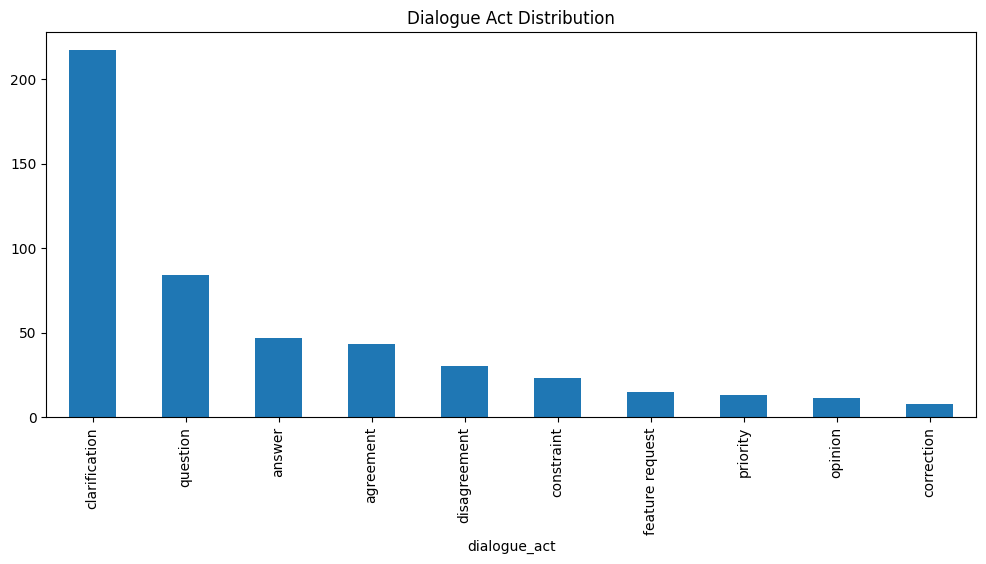

In [11]:
dialogue_distribution = (
    dialogue_df["dialogue_act"]
    .value_counts()
)

display(dialogue_distribution)

dialogue_distribution.plot(
    kind="bar",
    figsize=(12, 5),
    title="Dialogue Act Distribution"
)

In [12]:
dialogue_df.to_json(
    "statements_dialogue.json",
    orient="records",
    indent=2
)

dialogue_df.to_csv(
    "statements_dialogue.csv",
    index=False
)

In [13]:
ONTOLOGY_LABELS = [
    "actor",
    "system",
    "feature",
    "action",
    "object",
    "constraint",
    "business rule",
    "quality attribute",
    "condition",
    "trigger",
    "resource",
    "external system",
    "priority"
]

In [14]:
!pip install gliner

In [15]:
from gliner import GLiNER
model = GLiNER.from_pretrained("urchade/gliner_multi-v2.1")

try:
    from gliner import GLiNER

    gliner_model = GLiNER.from_pretrained(
        "urchade/gliner_multi-v2.1"
    )

    print("GLiNER loaded successfully.")

except Exception as e:
    print("GLiNER could not be loaded.")
    print(type(e).__name__, e)
    gliner_model = None

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 4.31MB            

spm.model: downloading bytes:           |  0.00B            

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

GLiNER loaded successfully.


In [16]:
ONTOLOGY_PATTERNS = {
    "actor": [
        "user",
        "users",
        "team",
        "team manager",
        "team administration",
        "referee",
        "referees",
        "fan",
        "fans",
        "player",
        "players",
        "ifa",
        "ifa representative",
        "ifa administrative"
    ],

    "feature": [
        "portal",
        "budget",
        "budgeting",
        "report",
        "reporting",
        "schedule",
        "scheduling",
        "notification",
        "fan portal",
        "mobile application",
        "web application",
        "authentication",
        "registration"
    ],

    "action": [
        "manage",
        "view",
        "access",
        "update",
        "insert",
        "register",
        "schedule",
        "assign",
        "export",
        "subscribe",
        "notify",
        "define",
        "monitor",
        "audit",
        "approve",
        "override",
        "report"
    ],

    "constraint": [
        "only",
        "must",
        "should",
        "cannot",
        "cannot be",
        "at least",
        "minimum",
        "maximum",
        "real time"
    ],

    "quality attribute": [
        "response time",
        "fast",
        "responsive",
        "performance",
        "security",
        "encrypted",
        "reliable",
        "transparency"
    ]
}

def extract_ontology_fallback(text):

    lower = text.lower()
    results = []

    for label, phrases in ONTOLOGY_PATTERNS.items():

        for phrase in phrases:

            if phrase in lower:

                results.append({
                    "text": phrase,
                    "label": label,
                    "score": 0.50
                })

    return results

def extract_ontology(text):

    if gliner_model is not None:
        try:
            return extract_ontology_gliner(text)
        except Exception:
            pass

    return extract_ontology_fallback(text)

ontology_records = []

for statement in statements:

    text = statement.normalized_text

    if statement.is_short:
        entities = []
    else:
        entities = extract_ontology(text)

    ontology_records.append({
        "statement_id": statement.statement_id,
        "turn_id": statement.turn_id,
        "speaker": statement.speaker,
        "timestamp": statement.timestamp,
        "normalized_text": text,
        "word_count": statement.word_count,
        "entities": entities
    })

print("Ontology records:", len(ontology_records))

ontology_df = pd.DataFrame(ontology_records)

print("Ontology DataFrame shape:", ontology_df.shape)
display(ontology_df.head())

Ontology records: 491
Ontology DataFrame shape: (491, 7)


,statement_id,turn_id,speaker,timestamp,normalized_text,word_count,entities
0,S001,T001,spk_0,0:00:00,we're doing I'm *** and this is **** we are co...,40,"[{'text': 'ifa', 'label': 'actor', 'score': 0.5}]"
1,S002,T001,spk_0,0:00:00,Yeah.,1,[]
2,S003,T001,spk_0,0:00:00,just can you give us 10 seconds?,7,[]
3,S004,T001,spk_0,0:00:00,We just need to start recording because.,7,[]
4,S005,T001,spk_0,0:00:00,Okay.,1,[]


In [17]:
import re
import pandas as pd

ontology_nodes = []

ontology_df = pd.DataFrame(
    ontology_records
)

display(ontology_df.head(20))

for _, row in ontology_df.iterrows():

    for entity in row["entities"]:

        normalized_label = re.sub(
            r"\s+",
            "_",
            entity["text"].lower()
        )

        node_id = (
            f"{entity['label']}::"
            f"{normalized_label}"
        )

        ontology_nodes.append({
            "node_id": node_id,
            "node_type": entity["label"],
            "label": entity["text"],
            "source_statement": row["statement_id"],
            "confidence": entity["score"]
        })

ontology_nodes_df = pd.DataFrame(
    ontology_nodes
)

display(ontology_nodes_df.head(30))

ontology_nodes_df.to_csv(
    "ontology_nodes.csv",
    index=False
)

,statement_id,turn_id,speaker,timestamp,normalized_text,word_count,entities
0,S001,T001,spk_0,0:00:00,we're doing I'm *** and this is **** we are co...,40,"[{'text': 'ifa', 'label': 'actor', 'score': 0.5}]"
1,S002,T001,spk_0,0:00:00,Yeah.,1,[]
2,S003,T001,spk_0,0:00:00,just can you give us 10 seconds?,7,[]
3,S004,T001,spk_0,0:00:00,We just need to start recording because.,7,[]
4,S005,T001,spk_0,0:00:00,Okay.,1,[]
5,S006,T001,spk_0,0:00:00,Okay.,1,[]
6,S007,T001,spk_0,0:00:00,So yes.,2,[]
7,S008,T001,spk_0,0:00:00,Now the video and our conversation is getting ...,9,[]
8,S009,T001,spk_0,0:00:00,All right.,2,[]
9,S010,T001,spk_0,0:00:00,So we understand that IFA's new system wants t...,13,"[{'text': 'ifa', 'label': 'actor', 'score': 0.5}]"


,node_id,node_type,label,source_statement,confidence
0,actor::ifa,actor,ifa,S001,0.5
1,actor::ifa,actor,ifa,S010,0.5
2,actor::user,actor,user,S011,0.5
3,actor::users,actor,users,S011,0.5
4,actor::fan,actor,fan,S011,0.5
5,actor::fans,actor,fans,S011,0.5
6,feature::portal,feature,portal,S011,0.5
7,feature::budget,feature,budget,S011,0.5
8,feature::report,feature,report,S011,0.5
9,feature::reporting,feature,reporting,S011,0.5


In [18]:
import networkx as nx

G = nx.MultiDiGraph(
    name="ARIA_NSRG_Discourse_Graph"
)

# --------------------------------------------------
# 1. Add statement nodes
# --------------------------------------------------

for _, row in dialogue_df.iterrows():

    G.add_node(
        f"statement::{row['statement_id']}",

        node_type="statement",

        statement_id=str(row["statement_id"]),

        turn_id=(
            str(row["turn_id"])
            if pd.notna(row["turn_id"])
            else None
        ),

        speaker=(
            str(row["speaker"])
            if pd.notna(row["speaker"])
            else "Unknown"
        ),

        timestamp=(
            str(row["timestamp"])
            if pd.notna(row["timestamp"])
            else None
        ),

        text=(
            str(row["original_text"])
            if pd.notna(row["original_text"])
            else str(row["normalized_text"])
        ),

        normalized_text=str(row["normalized_text"]),

        dialogue_act=(
            str(row["dialogue_act"])
            if pd.notna(row["dialogue_act"])
            else None
        ),

        dialogue_confidence=float(
            row["dialogue_confidence"]
        )
        if pd.notna(row["dialogue_confidence"])
        else 1.0
    )


# --------------------------------------------------
# 2. Add ontology nodes
# --------------------------------------------------

for _, row in ontology_nodes_df.iterrows():

    G.add_node(
        row["node_id"],
        node_type=str(row["node_type"]),
        label=str(row["label"]),
        source_statement=str(row["source_statement"]),
        confidence=float(row["confidence"])
    )


# --------------------------------------------------
# 3. Add statement → ontology edges
# --------------------------------------------------

for _, row in ontology_nodes_df.iterrows():

    statement_node = (
        f"statement::{row['source_statement']}"
    )

    ontology_node = row["node_id"]

    # Only create edge if source statement exists
    if statement_node in G:

        G.add_edge(
            statement_node,
            ontology_node,
            relation="mentions",
            confidence=float(row["confidence"])
        )


print(
    f"Successfully populated graph with "
    f"{G.number_of_nodes()} nodes and "
    f"{G.number_of_edges()} edges."
)

Successfully populated graph with 548 nodes and 499 edges.


In [19]:
print("Graph nodes:", G.number_of_nodes())
print("Graph edges:", G.number_of_edges())

print("\nFirst 5 statement nodes:")

for node, attrs in list(G.nodes(data=True))[:5]:

    if attrs.get("node_type") == "statement":

        print(node)
        print(attrs)
        print()

node_none_problems = []

for node, attrs in G.nodes(data=True):

    for key, value in attrs.items():

        if value is None:

            node_none_problems.append(
                (node, key, value)
            )

print(
    "Nodes with None attributes:",
    len(node_none_problems)
)

print("\nSample problems:")

for problem in node_none_problems[:20]:

    print(problem)

Graph nodes: 548
Graph edges: 499

First 5 statement nodes:
statement::S001
{'node_type': 'statement', 'statement_id': 'S001', 'turn_id': 'T001', 'speaker': 'spk_0', 'timestamp': '0:00:00', 'text': "we're doing I'm *** and this is **** we are colleagues and uh we are here for the IFA system and all the requirements that we'll now be discussing with you so that we can deliver a good system to you.", 'normalized_text': "we're doing I'm *** and this is **** we are colleagues and we are here for the IFA system and all the requirements that we'll now be discussing with you so that we can deliver a good system to you.", 'dialogue_act': 'disagreement', 'dialogue_confidence': 0.35417813062667847}

statement::S002
{'node_type': 'statement', 'statement_id': 'S002', 'turn_id': 'T001', 'speaker': 'spk_0', 'timestamp': '0:00:00', 'text': 'Yeah.', 'normalized_text': 'Yeah.', 'dialogue_act': 'clarification', 'dialogue_confidence': 0.2715657353401184}

statement::S003
{'node_type': 'statement', 'state

In [20]:
print("dialogue_df shape:", dialogue_df.shape)
print("\ndialogue_df columns:")
print(dialogue_df.columns.tolist())

print("\nFirst 3 rows:")
display(dialogue_df.head(3))

print("Number of statements:", len(statements))

print("\nFirst statement:")
print(statements[0])

dialogue_df shape: (491, 13)

dialogue_df columns:
['statement_id', 'turn_id', 'speaker', 'timestamp', 'timestamp_seconds', 'original_text', 'normalized_text', 'position_in_turn', 'word_count', 'is_short', 'has_redacted_name', 'dialogue_act', 'dialogue_confidence']

First 3 rows:


,statement_id,turn_id,speaker,timestamp,timestamp_seconds,original_text,normalized_text,position_in_turn,word_count,is_short,has_redacted_name,dialogue_act,dialogue_confidence
0,S001,T001,spk_0,0:00:00,0,we're doing I'm *** and this is **** we are co...,we're doing I'm *** and this is **** we are co...,0,40,False,True,disagreement,0.354178
1,S002,T001,spk_0,0:00:00,0,Yeah.,Yeah.,1,1,True,False,clarification,0.271566
2,S003,T001,spk_0,0:00:00,0,Um Uh just just can you give us 10 seconds?,just can you give us 10 seconds?,2,7,False,False,question,0.319468


Number of statements: 491

First statement:
Statement(statement_id='S001', turn_id='T001', speaker='spk_0', timestamp='0:00:00', timestamp_seconds=0, original_text="we're doing I'm *** and this is **** we are colleagues and uh we are here for the IFA system and all the requirements that we'll now be discussing with you so that we can deliver a good system to you.", normalized_text="we're doing I'm *** and this is **** we are colleagues and we are here for the IFA system and all the requirements that we'll now be discussing with you so that we can deliver a good system to you.", position_in_turn=0, word_count=40, is_short=False, has_redacted_name=True, dialogue_act='disagreement', dialogue_confidence=0.35417813062667847)


In [21]:
ordered_ids = dialogue_df["statement_id"].tolist()

# 1. Add "follows" edges
for i in range(len(ordered_ids) - 1):
    current_id = ordered_ids[i]
    next_id = ordered_ids[i + 1]

    G.add_edge(
        f"statement::{current_id}",
        f"statement::{next_id}",
        relation="follows"
    )

# 2. Add "answered_by" edges
for i, row in dialogue_df.iterrows():
    dialogue_act = row.get("dialogue_act", None)
    text = str(row.get("normalized_text", "")).strip()

    # Determine if it's a question via column or text ending
    is_question = (
        dialogue_act == "question" or
        text.endswith("?") or
        text.lower().startswith(("what", "why", "how", "who", "where", "when", "is", "are", "can", "do", "does"))
    )

    if not is_question:
        continue

    question_id = row["statement_id"]
    question_speaker = row.get("speaker", "speaker_1")

    for j in range(i + 1, min(i + 4, len(dialogue_df))):
        candidate = dialogue_df.iloc[j]
        candidate_speaker = candidate.get("speaker", "speaker_2")

        # If speakers are distinct or unassigned, assume the next turn is the answer
        if candidate_speaker != question_speaker or "speaker" not in dialogue_df.columns:
            answer_id = candidate["statement_id"]

            G.add_edge(
                f"statement::{question_id}",
                f"statement::{answer_id}",
                relation="answered_by"
            )
            break

# 3. Add "refines_or_contradicts" edges
CORRECTION_WORDS = [
    "actually", "no no", "no,", "instead", "rather",
    "not", "only", "you are right", "that's not", "no there is"
]

def looks_like_correction(text):
    t = text.lower()
    return any(phrase in t for phrase in CORRECTION_WORDS)

for i, row in dialogue_df.iterrows():
    if i == 0:
        continue

    current_text = row.get("normalized_text", "")
    dialogue_act = row.get("dialogue_act", None)

    is_correction = (
        dialogue_act in ["correction", "disagreement"] or
        looks_like_correction(current_text)
    )

    if not is_correction:
        continue

    current_id = row["statement_id"]

    # Examine previous 5 statements
    for j in range(max(0, i - 5), i):
        previous = dialogue_df.iloc[j]
        previous_id = previous["statement_id"]

        G.add_edge(
            f"statement::{current_id}",
            f"statement::{previous_id}",
            relation="refines_or_contradicts"
        )

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

texts = dialogue_df[
    "normalized_text"
].tolist()

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1
)

tfidf_matrix = vectorizer.fit_transform(texts)

similarity_matrix = cosine_similarity(
    tfidf_matrix
)

print(similarity_matrix.shape)

(491, 491)


In [23]:
# Export discourse graph to GraphML

G_clean = G.copy()

# Defensive cleanup: GraphML cannot store None values
for node, data in G_clean.nodes(data=True):
    for key, val in list(data.items()):
        if val is None:
            data[key] = ""

for u, v, k, data in G_clean.edges(
    keys=True,
    data=True
):
    for key, val in list(data.items()):
        if val is None:
            data[key] = ""

nx.write_graphml(
    G_clean,
    "04_discourse_graph.graphml"
)

print("Graph saved successfully!")

Graph saved successfully!


In [24]:
import pandas as pd

dialogue_df = pd.read_json(
    "statements_dialogue.json"
)

print(dialogue_df.columns.tolist())
print(dialogue_df.shape)

display(
    dialogue_df[
        [
            "statement_id",
            "normalized_text",
            "dialogue_act",
            "dialogue_confidence"
        ]
    ].head(10)
)

['statement_id', 'turn_id', 'speaker', 'timestamp', 'timestamp_seconds', 'original_text', 'normalized_text', 'position_in_turn', 'word_count', 'is_short', 'has_redacted_name', 'dialogue_act', 'dialogue_confidence']
(491, 13)


,statement_id,normalized_text,dialogue_act,dialogue_confidence
0,S001,we're doing I'm *** and this is **** we are co...,disagreement,0.354178
1,S002,Yeah.,clarification,0.271566
2,S003,just can you give us 10 seconds?,question,0.319468
3,S004,We just need to start recording because.,clarification,0.241524
4,S005,Okay.,clarification,0.314228
5,S006,Okay.,clarification,0.314228
6,S007,So yes.,answer,0.375142
7,S008,Now the video and our conversation is getting ...,constraint,0.288612
8,S009,All right.,clarification,0.340910
9,S010,So we understand that IFA's new system wants t...,feature request,0.331044


In [26]:
from dataclasses import dataclass, field
from typing import Optional, List

@dataclass
class RequirementFrame:

    frame_id: str

    actor: Optional[str] = None
    action: Optional[str] = None
    object: Optional[str] = None
    feature: Optional[str] = None
    condition: Optional[str] = None
    constraint: Optional[str] = None
    business_rule: Optional[str] = None
    quality_attribute: Optional[str] = None
    priority: Optional[str] = None

    source_statements: List[str] = field(
        default_factory=list
    )

    status: str = "candidate"
    validation_issues: List[str] = field(
        default_factory=list
    )

REQUIREMENT_PATTERNS = re.compile(
    r"\b("
    r"should|must|need to|needs to|"
    r"would like|want|allow|"
    r"be able to|has to|"
    r"only|at least|minimum|maximum|"
    r"the system|"
    r"require|required|"
    r"shall"
    r")\b",
    re.IGNORECASE
)


# Short conversational acknowledgements that should
# never become requirement candidates.
NON_REQUIREMENT_SHORT = {
    "yeah",
    "yes",
    "no",
    "okay",
    "ok",
    "all right",
    "alright",
    "indeed",
    "go ahead",
    "sure",
    "fine",
    "right"
}


def is_requirement_candidate(row):

    text = row["normalized_text"].strip()
    act = row["dialogue_act"]

    text_lower = text.lower()

    # -----------------------------------------
    # 1. Reject very short conversational text
    # -----------------------------------------

    if row["word_count"] <= 3:
        return False

    if text_lower in NON_REQUIREMENT_SHORT:
        return False

    # -----------------------------------------
    # 2. Strong dialogue-act evidence
    # -----------------------------------------

    strong_act_candidate = act in {
        "feature request",
        "constraint",
        "priority",
        "correction"
    }

    # -----------------------------------------
    # 3. Linguistic requirement evidence
    # -----------------------------------------

    linguistic_candidate = bool(
        REQUIREMENT_PATTERNS.search(text)
    )

    # -----------------------------------------
    # 4. Clarifications are NOT automatically
    #    requirements anymore.
    #
    #    A clarification only qualifies if the
    #    text itself contains requirement language.
    # -----------------------------------------

    if act == "clarification":
        return linguistic_candidate

    return (
        strong_act_candidate
        or linguistic_candidate
    )

dialogue_df[
    "requirement_candidate"
] = dialogue_df.apply(
    is_requirement_candidate,
    axis=1
)

candidate_df = dialogue_df[
    dialogue_df["requirement_candidate"]
].copy()

print(
    "Candidate statements:",
    len(candidate_df)
)

def ontology_for_statement(statement_id):

    return ontology_nodes_df[
        ontology_nodes_df[
            "source_statement"
        ] == statement_id
    ].to_dict("records")

def build_requirement_frame(row):

    entities = ontology_for_statement(
        row["statement_id"]
    )

    frame = RequirementFrame(
        frame_id=f"RF-{row['statement_id']}",
        source_statements=[
            row["statement_id"]
        ]
    )

    # Collect all ontology values by type
    grouped = {}

    for entity in entities:

        label = entity["node_type"]
        value = entity["label"]

        if not value:
            continue

        grouped.setdefault(label, []).append(value)

    # -----------------------------------------
    # Select primary symbolic values
    # -----------------------------------------

    if grouped.get("actor"):
        frame.actor = grouped["actor"][0]

    if grouped.get("action"):
        frame.action = grouped["action"][0]

    if grouped.get("object"):
        frame.object = grouped["object"][0]

    if grouped.get("feature"):
        frame.feature = grouped["feature"][0]

    if grouped.get("condition"):
        frame.condition = grouped["condition"][0]

    if grouped.get("constraint"):
        frame.constraint = grouped["constraint"][0]

    if grouped.get("business rule"):
        frame.business_rule = grouped["business rule"][0]

    if grouped.get("quality attribute"):
        frame.quality_attribute = grouped["quality attribute"][0]

    if grouped.get("priority"):
        frame.priority = grouped["priority"][0]

    return frame

frames = []

for _, row in candidate_df.iterrows():

    frame = build_requirement_frame(row)

    related = get_related_statements(
        row["statement_id"],
        max_depth=1
    )

    for sid in related:

        if sid not in frame.source_statements:
            frame.source_statements.append(sid)

    frames.append(frame)

print(
    "Generated frames:",
    len(frames)
)

for frame in frames:
    validate_frame(frame)

frame_status = pd.Series(
    [f.status for f in frames]
)

display(
    frame_status.value_counts()
)

for i, frame in enumerate(frames[:10], start=1):

    print(f"\n--- Frame {i} ---")
    print(json.dumps(
        frame_to_dict(frame),
        indent=2
    ))

Candidate statements: 128
Generated frames: 128


,count
valid,81
needs_review,47



--- Frame 1 ---
{
  "actor": null,
  "action": null,
  "object": null,
  "feature": null,
  "condition": null,
  "constraint": null,
  "business_rule": null,
  "quality_attribute": null,
  "priority": null
}

--- Frame 2 ---
{
  "actor": null,
  "action": null,
  "object": null,
  "feature": null,
  "condition": null,
  "constraint": null,
  "business_rule": null,
  "quality_attribute": null,
  "priority": null
}

--- Frame 3 ---
{
  "actor": "ifa",
  "action": null,
  "object": null,
  "feature": null,
  "condition": null,
  "constraint": null,
  "business_rule": null,
  "quality_attribute": null,
  "priority": null
}

--- Frame 4 ---
{
  "actor": "user",
  "action": "report",
  "object": null,
  "feature": "portal",
  "condition": null,
  "constraint": null,
  "business_rule": null,
  "quality_attribute": null,
  "priority": null
}

--- Frame 5 ---
{
  "actor": "system",
  "action": null,
  "object": null,
  "feature": "budget",
  "condition": null,
  "constraint": null,
  "business

In [27]:
def get_related_statements(
    statement_id,
    max_depth=1
):

    start = f"statement::{statement_id}"

    if start not in G:
        return []

    related_nodes = nx.single_source_shortest_path_length(
        G,
        start,
        cutoff=max_depth
    )

    result = []

    for node in related_nodes:

        if node.startswith("statement::"):

            sid = node.replace(
                "statement::",
                ""
            )

            if sid != statement_id:
                result.append(sid)

    return result

frames = []

for _, row in candidate_df.iterrows():

    frame = build_requirement_frame(row)

    related = get_related_statements(
        row["statement_id"],
        max_depth=1
    )

    for sid in related:

        if sid not in frame.source_statements:

            frame.source_statements.append(
                sid
            )

    frames.append(frame)

print(
    "Generated frames:",
    len(frames)
)

def validate_frame(frame):

    issues = []

    # -----------------------------------------
    # 1. Check whether the frame contains
    #    actual requirement semantics
    # -----------------------------------------

    has_capability = bool(
        frame.action
        or frame.feature
        or frame.object
    )

    has_constraint = bool(
        frame.constraint
        or frame.business_rule
        or frame.quality_attribute
    )

    has_evidence = bool(
        frame.source_statements
    )

    # -----------------------------------------
    # 2. A frame must contain actionable
    #    semantic content
    # -----------------------------------------

    if not has_capability and not has_constraint:

        issues.append(
            "No actionable semantic content"
        )

    # -----------------------------------------
    # 3. Provenance is mandatory
    # -----------------------------------------

    if not has_evidence:

        issues.append(
            "Missing provenance"
        )

    # -----------------------------------------
    # 4. Default actor only AFTER semantic
    #    content has been established
    # -----------------------------------------

    if (
        not frame.actor
        and
        (has_capability or has_constraint)
    ):
        frame.actor = "system"

    # -----------------------------------------
    # 5. Validate
    # -----------------------------------------

    frame.validation_issues = issues

    if issues:
        frame.status = "needs_review"
    else:
        frame.status = "valid"

    return frame

for frame in frames:
    validate_frame(frame)

frame_status = pd.Series(
    [f.status for f in frames]
)

display(
    frame_status.value_counts()
)
for frame in frames:
    validate_frame(frame)

frame_status = pd.Series(
    [f.status for f in frames]
)

display(
    frame_status.value_counts()
)
for i, frame in enumerate(frames[:10], start=1):

    print(f"\n--- Frame {i} ---")

    print(
        json.dumps(
            frame_to_dict(frame),
            indent=2
        )
    )

    print(
        "Status:",
        frame.status
    )

    print(
        "Issues:",
        frame.validation_issues
    )

    print(
        "Evidence:",
        frame.source_statements
    )

Generated frames: 128


,count
valid,81
needs_review,47


,count
valid,81
needs_review,47



--- Frame 1 ---
{
  "actor": null,
  "action": null,
  "object": null,
  "feature": null,
  "condition": null,
  "constraint": null,
  "business_rule": null,
  "quality_attribute": null,
  "priority": null
}
Status: needs_review
Issues: ['No actionable semantic content']
Evidence: ['S004', 'S005']

--- Frame 2 ---
{
  "actor": null,
  "action": null,
  "object": null,
  "feature": null,
  "condition": null,
  "constraint": null,
  "business_rule": null,
  "quality_attribute": null,
  "priority": null
}
Status: needs_review
Issues: ['No actionable semantic content']
Evidence: ['S008', 'S009']

--- Frame 3 ---
{
  "actor": "ifa",
  "action": null,
  "object": null,
  "feature": null,
  "condition": null,
  "constraint": null,
  "business_rule": null,
  "quality_attribute": null,
  "priority": null
}
Status: needs_review
Issues: ['No actionable semantic content']
Evidence: ['S010', 'S011']

--- Frame 4 ---
{
  "actor": "user",
  "action": "report",
  "object": null,
  "feature": "portal"

In [28]:
print("Ontology node types:")
print(
    ontology_nodes_df["node_type"]
    .value_counts()
)
print("\nSample ontology nodes:")

display(
    ontology_nodes_df[
        [
            "node_id",
            "node_type",
            "label",
            "source_statement",
            "confidence"
        ]
    ].head(20)
)

Ontology node types:
node_type
actor                213
feature              121
action               104
constraint            48
quality attribute     13
Name: count, dtype: int64

Sample ontology nodes:


,node_id,node_type,label,source_statement,confidence
0,actor::ifa,actor,ifa,S001,0.5
1,actor::ifa,actor,ifa,S010,0.5
2,actor::user,actor,user,S011,0.5
3,actor::users,actor,users,S011,0.5
4,actor::fan,actor,fan,S011,0.5
5,actor::fans,actor,fans,S011,0.5
6,feature::portal,feature,portal,S011,0.5
7,feature::budget,feature,budget,S011,0.5
8,feature::report,feature,report,S011,0.5
9,feature::reporting,feature,reporting,S011,0.5


In [29]:
import inspect

print(inspect.getsource(build_requirement_frame))

def build_requirement_frame(row):

    entities = ontology_for_statement(
        row["statement_id"]
    )

    frame = RequirementFrame(
        frame_id=f"RF-{row['statement_id']}",
        source_statements=[
            row["statement_id"]
        ]
    )

    # Collect all ontology values by type
    grouped = {}

    for entity in entities:

        label = entity["node_type"]
        value = entity["label"]

        if not value:
            continue

        grouped.setdefault(label, []).append(value)

    # -----------------------------------------
    # Select primary symbolic values
    # -----------------------------------------

    if grouped.get("actor"):
        frame.actor = grouped["actor"][0]

    if grouped.get("action"):
        frame.action = grouped["action"][0]

    if grouped.get("object"):
        frame.object = grouped["object"][0]

    if grouped.get("feature"):
        frame.feature = grouped["feature"][0]

    if grouped.get("condition"):
        frame.co

In [30]:
valid_frames = [
    frame
    for frame in frames
    if frame.status == "valid"
]

print("Number of valid frames:", len(valid_frames))

Number of valid frames: 81


In [31]:
print("candidate_df shape:", candidate_df.shape)

print("\nCandidate columns:")
print(candidate_df.columns.tolist())

print("\nFirst 20 candidate statements:")
display(
    candidate_df[
        [
            "statement_id",
            "dialogue_act",
            "requirement_candidate",
            "normalized_text"
        ]
    ].head(20)
)

print("\nS013/S014 in candidate_df:")

display(
    candidate_df[
        candidate_df["statement_id"].isin(
            ["S013", "S014"]
        )
    ][
        [
            "statement_id",
            "dialogue_act",
            "requirement_candidate",
            "normalized_text"
        ]
    ]
)

candidate_df shape: (128, 14)

Candidate columns:
['statement_id', 'turn_id', 'speaker', 'timestamp', 'timestamp_seconds', 'original_text', 'normalized_text', 'position_in_turn', 'word_count', 'is_short', 'has_redacted_name', 'dialogue_act', 'dialogue_confidence', 'requirement_candidate']

First 20 candidate statements:


,statement_id,dialogue_act,requirement_candidate,normalized_text
3,S004,clarification,True,We just need to start recording because.
7,S008,constraint,True,Now the video and our conversation is getting ...
9,S010,feature request,True,So we understand that IFA's new system wants t...
10,S011,feature request,True,"For example, you need a proper budget, budgett..."
12,S013,clarification,True,"So regarding the budget, We want to know the b..."
20,S021,constraint,True,So it's such as a small stadium that the team ...
22,S023,constraint,True,A b maintenance expenses for the study and thi...
29,S030,clarification,True,The IFA only controls the ballance and monitor...
30,S031,clarification,True,The responsibility for managing the budget is ...
31,S032,correction,True,"Sorry, sorry to interrupt."



S013/S014 in candidate_df:


,statement_id,dialogue_act,requirement_candidate,normalized_text
12,S013,clarification,True,"So regarding the budget, We want to know the b..."


In [32]:
print("dialogue_df statement IDs:")
print(dialogue_df["statement_id"].head(10).tolist())

print("\nontology_df statement IDs:")
print(ontology_df["statement_id"].head(10).tolist())

print("\nontology_nodes_df source_statement:")
print(ontology_nodes_df["source_statement"].head(10).tolist())

print("\nTypes:")
print(
    type(dialogue_df["statement_id"].iloc[0]),
    type(ontology_df["statement_id"].iloc[0]),
    type(ontology_nodes_df["source_statement"].iloc[0])
)

dialogue_df statement IDs:
['S001', 'S002', 'S003', 'S004', 'S005', 'S006', 'S007', 'S008', 'S009', 'S010']

ontology_df statement IDs:
['S001', 'S002', 'S003', 'S004', 'S005', 'S006', 'S007', 'S008', 'S009', 'S010']

ontology_nodes_df source_statement:
['S001', 'S010', 'S011', 'S011', 'S011', 'S011', 'S011', 'S011', 'S011', 'S011']

Types:
<class 'str'> <class 'str'> <class 'str'>


In [33]:
valid_frames = [
    f for f in frames
    if f.status == "valid"
]

review_frames = [
    f for f in frames
    if f.status == "needs_review"
]

print(
    "Valid:",
    len(valid_frames)
)

print(
    "Needs review:",
    len(review_frames)
)

Valid: 81
Needs review: 47


In [34]:
for sid in ["S011", "S012"]:

    row = dialogue_df[
        dialogue_df["statement_id"] == sid
    ].iloc[0]

    print(f"\n--- {sid} ---")
    print("Speaker:", row["speaker"])
    print("Dialogue act:", row["dialogue_act"])
    print("Candidate:", row["requirement_candidate"])
    print("Original:")
    print(row["original_text"])
    print("Normalized:")
    print(row["normalized_text"])

frame2 = valid_frames[1]

print(
    "Frame 2 source statements:",
    frame2.source_statements
)

for sid in frame2.source_statements:

    row = dialogue_df[
        dialogue_df["statement_id"] == sid
    ].iloc[0]

    print(f"\n--- {sid} ---")
    print(row["original_text"])


--- S011 ---
Speaker: spk_0
Dialogue act: feature request
Candidate: True
Original:
For example, you need a proper budget, budgetting portal, reporting portal, scheduling portal and a fan portal for your consumers, fans, users.
Normalized:
For example, you need a proper budget, budgetting portal, reporting portal, scheduling portal and a fan portal for your consumers, fans, users.

--- S012 ---
Speaker: spk_0
Dialogue act: question
Candidate: False
Original:
So we'll go one by one, uh and we'll ask you some questions regarding each of these key categories and then um maybe you can add whatever we have missed and we'll just round it up nicely.
Normalized:
So we'll go one by one, and we'll ask you some questions regarding each of these key categories and then maybe you can add whatever we have missed and we'll just round it up nicely.
Frame 2 source statements: ['S013', 'S014']

--- S013 ---
So uh regarding the budget, uh We want to know the basics first.

--- S014 ---
So uh how is the 

In [35]:
for frame in valid_frames[:30]:

    print("=" * 100)

    print(frame.frame_id)

    print(
        "Actor:",
        frame.actor
    )

    print(
        "Action:",
        frame.action
    )

    print(
        "Object:",
        frame.object
    )

    print(
        "Feature:",
        frame.feature
    )

    print(
        "Constraint:",
        frame.constraint
    )

    print(
        "Sources:",
        frame.source_statements
    )


RF-S011
Actor: user
Action: report
Object: None
Feature: portal
Constraint: None
Sources: ['S011', 'S012']
RF-S013
Actor: system
Action: None
Object: None
Feature: budget
Constraint: None
Sources: ['S013', 'S014']
RF-S030
Actor: ifa
Action: manage
Object: None
Feature: None
Constraint: only
Sources: ['S030', 'S031', 'S025', 'S026', 'S027', 'S028', 'S029']
RF-S031
Actor: team
Action: None
Object: None
Feature: budget
Constraint: only
Sources: ['S031', 'S032', 'S026', 'S027', 'S028', 'S029', 'S030']
RF-S033
Actor: ifa
Action: audit
Object: None
Feature: None
Constraint: only
Sources: ['S033', 'S034', 'S028', 'S029', 'S030', 'S031', 'S032']
RF-S034
Actor: system
Action: None
Object: None
Feature: budget
Constraint: should
Sources: ['S034', 'S035']
RF-S076
Actor: referee
Action: insert
Object: None
Feature: None
Constraint: None
Sources: ['S076', 'S077']
RF-S079
Actor: referee
Action: insert
Object: None
Feature: None
Constraint: only
Sources: ['S079', 'S080', 'S074', 'S075', 'S076', 'S077

In [36]:
!pip install -q groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 7.4 MB/s eta 0:00:00


In [46]:
from groq import Groq

# Using the provided API key directly
GROQ_API_KEY = "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"

client = Groq(api_key=GROQ_API_KEY)
GENERATION_MODEL = "llama3-70b-8192" # Updated to a valid Groq model ID
print(f"Groq client initialized with model: {GENERATION_MODEL}")

Groq client initialized with model: llama3-70b-8192


In [47]:
# Check the models available to your Groq API key

available_models = client.models.list()

print("Available Groq models:")

for model in available_models.data:
    print(" -", model.id)

Available Groq models:
 - whisper-large-v3-turbo
 - canopylabs/orpheus-arabic-saudi
 - whisper-large-v3
 - groq/compound-mini
 - meta-llama/llama-prompt-guard-2-86m
 - groq/compound
 - qwen/qwen3.6-27b
 - meta-llama/llama-prompt-guard-2-22m
 - openai/gpt-oss-120b
 - canopylabs/orpheus-v1-english
 - openai/gpt-oss-20b
 - qwen/qwen3.8-27b
 - openai/gpt-oss-safeguard-20b
 - allam-2-7b


In [48]:
GENERATION_MODEL = "openai/gpt-oss-120b"

print("Using model:", GENERATION_MODEL)


Using model: openai/gpt-oss-120b


In [49]:
def frame_to_dict(frame):

    return {
        "actor": frame.actor,
        "action": frame.action,
        "object": frame.object,
        "feature": frame.feature,
        "condition": frame.condition,
        "constraint": frame.constraint,
        "business_rule": frame.business_rule,
        "quality_attribute": frame.quality_attribute,
        "priority": frame.priority
    }


def realize_requirement(frame):

    frame_json = json.dumps(
        frame_to_dict(frame),
        indent=2
    )

    prompt = f"""
You are a software requirements engineer.

The logical structure below has already been
constructed and validated by a symbolic reasoning system.

Your ONLY task is to convert it into one concise,
professional software system requirement.

Rules:
1. Do not invent information.
2. Do not add functionality.
3. Do not introduce actors not present in the frame.
4. Do not introduce constraints not present in the frame.
5. Do not infer unstated quality attributes.
6. Preserve the meaning exactly.
7. Return only ONE requirement.
8. Prefer "The system shall ..." wording.

Verified RequirementFrame:

{frame_json}
"""

    response = client.chat.completions.create(
        model=GENERATION_MODEL,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0
    )

    return response.choices[0].message.content.strip()


# Test with ONE valid frame
if valid_frames:

    test_requirement = realize_requirement(
        valid_frames[0]
    )

    print(test_requirement)

The system shall enable the user to report via the portal.


In [50]:
def detect_suspicious_terms(requirement_text):

    if not requirement_text:
        return []

    suspicious_terms = []

    text = requirement_text.lower()

    # Terms that may indicate the LLM introduced
    # unsupported functionality or assumptions.
    suspicious_patterns = [
        "automatically",
        "real-time",
        "secure",
        "securely",
        "efficiently",
        "seamlessly",
        "intelligently",
        "advanced",
        "enhanced",
        "scalable",
        "user-friendly",
        "high performance",
        "encrypted",
        "encryption",
        "analytics",
        "dashboard",
        "api",
        "database",
        "email",
        "sms",
        "mobile app",
        "authentication"
    ]

    for term in suspicious_patterns:

        if term in text:
            suspicious_terms.append(term)

    return suspicious_terms

In [52]:
import time

print(f"Frames to realize: {len(valid_frames)}")
final_requirements = []
generated_count = 0

for i, frame in enumerate(valid_frames):
    req_id = f"REQ-{i+1:03d}"
    try:
        # Add a delay to respect Groq TPM rate limits
        if i > 0:
            time.sleep(2.0)

        requirement_text = realize_requirement(frame)
        generated_count += 1
        print(f"Generated {req_id} ({frame.frame_id})")
    except Exception as e:
        requirement_text = None
        print(f"Error generating {frame.frame_id}: {e}")

    evidence = []
    for sid in frame.source_statements:
        # Check if statement exists in dialogue_df
        matches = dialogue_df[dialogue_df["statement_id"] == sid]
        if not matches.empty:
            row = matches.iloc[0]
            evidence.append({
                "statement_id": row["statement_id"],
                "turn_id": row["turn_id"],
                "speaker": row["speaker"],
                "timestamp": str(row["timestamp"]),
                "original_text": row["original_text"],
                "dialogue_act": row["dialogue_act"]
            })

    final_requirements.append({
        "requirement_id": req_id,
        "requirement": requirement_text,
        "frame_id": frame.frame_id,
        "source_statements": frame.source_statements,
        "evidence": evidence,
        "suspicious_terms": detect_suspicious_terms(requirement_text or "")
    })

# Reconstruct evaluation_rows for evaluation_df
evaluation_rows = []
for req in final_requirements:
    evaluation_rows.append({
        "requirement_id": req["requirement_id"],
        "requirement": req["requirement"],
        "traceable": len(req["evidence"]) > 0,
        "suspicious_terms": ", ".join(req["suspicious_terms"])
    })
evaluation_df = pd.DataFrame(evaluation_rows)
print(f"\nSuccessfully generated {generated_count} requirements.")

Frames to realize: 81
Generated REQ-001 (RF-S011)
Generated REQ-002 (RF-S013)
Generated REQ-003 (RF-S030)
Generated REQ-004 (RF-S031)
Generated REQ-005 (RF-S033)
Generated REQ-006 (RF-S034)
Generated REQ-007 (RF-S076)
Generated REQ-008 (RF-S079)
Generated REQ-009 (RF-S080)
Generated REQ-010 (RF-S081)
Generated REQ-011 (RF-S094)
Generated REQ-012 (RF-S096)
Generated REQ-013 (RF-S097)
Generated REQ-014 (RF-S103)
Generated REQ-015 (RF-S105)
Generated REQ-016 (RF-S111)
Generated REQ-017 (RF-S120)
Generated REQ-018 (RF-S122)
Generated REQ-019 (RF-S124)
Generated REQ-020 (RF-S140)
Generated REQ-021 (RF-S145)
Generated REQ-022 (RF-S156)
Generated REQ-023 (RF-S162)
Generated REQ-024 (RF-S165)
Generated REQ-025 (RF-S167)
Generated REQ-026 (RF-S172)
Generated REQ-027 (RF-S176)
Generated REQ-028 (RF-S179)
Generated REQ-029 (RF-S180)
Generated REQ-030 (RF-S186)
Generated REQ-031 (RF-S187)
Generated REQ-032 (RF-S190)
Generated REQ-033 (RF-S193)
Generated REQ-034 (RF-S194)
Generated REQ-035 (RF-S195

In [53]:
print("Number of frames:", len(frames))
print("Valid frames:", len(valid_frames))
print("Review frames:", len(review_frames))
print("Generated requirements:", len(generated_requirements))
print("Final requirements:", len(final_requirements))

print("\nFrame statuses:")
print(
    pd.Series(
        [f.status for f in frames]
    ).value_counts()
)

print(len(candidate_df))

len(final_requirements)

Number of frames: 128
Valid frames: 81
Review frames: 47


NameError: name 'generated_requirements' is not defined

In [54]:
requirement_texts = [
    r["requirement"]
    for r in final_requirements
    if r["requirement"]
]

if requirement_texts:

    req_vectorizer = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2)
    )

    req_matrix = req_vectorizer.fit_transform(
        requirement_texts
    )

    req_similarity = cosine_similarity(
        req_matrix
    )

DUPLICATE_THRESHOLD = 0.75

duplicate_pairs = []

for i in range(
    len(requirement_texts)
):

    for j in range(
        i + 1,
        len(requirement_texts)
    ):

        score = req_similarity[i, j]

        if score >= DUPLICATE_THRESHOLD:

            duplicate_pairs.append({
                "requirement_a": i,
                "requirement_b": j,
                "similarity": float(score)
            })

print(
    "Potential duplicate pairs:",
    len(duplicate_pairs)
)

duplicate_pairs = []

for i in range(len(requirement_texts)):

    for j in range(i + 1, len(requirement_texts)):

        score = req_similarity[i, j]

        if score >= DUPLICATE_THRESHOLD:

            duplicate_pairs.append({
                "requirement_a": final_requirements[i]["requirement_id"],
                "requirement_b": final_requirements[j]["requirement_id"],
                "similarity": float(score),
                "text_a": requirement_texts[i],
                "text_b": requirement_texts[j]
            })

print(
    "Potential duplicate pairs:",
    len(duplicate_pairs)
)

duplicate_df = pd.DataFrame(duplicate_pairs)

display(
    duplicate_df.sort_values(
        "similarity",
        ascending=False
    ).head(20)
)

evaluation_df = pd.DataFrame(
    evaluation_rows
)

display(evaluation_df.head(20))

traceability_rate = (
    evaluation_df["traceable"]
    .mean()
)

print(
    f"Traceability coverage: "
    f"{traceability_rate:.2%}"
)

Potential duplicate pairs: 22
Potential duplicate pairs: 22


,requirement_a,requirement_b,similarity,text_a,text_b
3,REQ-010,REQ-046,1.0,The system shall permit updates only by the re...,The system shall permit updates only by the re...
2,REQ-007,REQ-081,1.0,The system shall allow the referee to insert.,The system shall allow the referee to insert.
5,REQ-015,REQ-052,1.0,The system shall enable the team to report.,The system shall enable the team to report.
6,REQ-018,REQ-045,1.0,The system shall only access.,The system shall access.
1,REQ-002,REQ-073,1.0,The system shall provide budget functionality.,The system shall provide budget functionality.
0,REQ-002,REQ-055,1.0,The system shall provide budget functionality.,The system shall provide budget functionality.
4,REQ-014,REQ-060,1.0,The system shall report.,The system shall report.
7,REQ-020,REQ-028,1.0,The system shall schedule.,The system shall schedule.
8,REQ-020,REQ-029,1.0,The system shall schedule.,The system shall schedule.
10,REQ-025,REQ-027,1.0,The system shall not.,The system shall not.


,requirement_id,requirement,traceable,suspicious_terms
0,REQ-001,The system shall enable the user to report via...,True,
1,REQ-002,The system shall provide budget functionality.,True,
2,REQ-003,The system shall permit management actions onl...,True,
3,REQ-004,The system shall allow only the team to access...,True,
4,REQ-005,The system shall allow only the ifa to perform...,True,
5,REQ-006,The system should include a budget feature.,True,
6,REQ-007,The system shall allow the referee to insert.,True,
7,REQ-008,The system shall permit insertion only by the ...,True,
8,REQ-009,The system shall be reliable.,True,
9,REQ-010,The system shall permit updates only by the re...,True,


Traceability coverage: 100.00%


In [55]:
none_node_attrs = []

for node, attrs in G.nodes(data=True):
    for key, value in attrs.items():
        if value is None:
            none_node_attrs.append(
                (node, key, value)
            )

none_edge_attrs = []

for source, target, attrs in G.edges(data=True):
    for key, value in attrs.items():
        if value is None:
            none_edge_attrs.append(
                (source, target, key, value)
            )

print("Nodes with None attributes:", len(none_node_attrs))
print("Edges with None attributes:", len(none_edge_attrs))

print("\nSample node problems:")
for item in none_node_attrs[:20]:
    print(item)

print("\nSample edge problems:")
for item in none_edge_attrs[:20]:
    print(item)

Nodes with None attributes: 0
Edges with None attributes: 0

Sample node problems:

Sample edge problems:


In [56]:
first_statement_id = statements[0].statement_id

node_id = f"statement::{first_statement_id}"

print("Statement node:", node_id)

if node_id in G:
    print("\nGraph node attributes:")
    print(G.nodes[node_id])
else:
    print("\nERROR: Statement node not found in graph.")

print("\nFirst Statement object:")
print(statements[0])

print("\nFirst Statement attributes:")
print("statement_id:", statements[0].statement_id)
print("turn_id:", statements[0].turn_id)
print("speaker:", statements[0].speaker)
print("timestamp:", statements[0].timestamp)
print("dialogue_act:", getattr(statements[0], "dialogue_act", None))
print("normalized_text:", statements[0].normalized_text)

Statement node: statement::S001

Graph node attributes:
{'node_type': 'statement', 'statement_id': 'S001', 'turn_id': 'T001', 'speaker': 'spk_0', 'timestamp': '0:00:00', 'text': "we're doing I'm *** and this is **** we are colleagues and uh we are here for the IFA system and all the requirements that we'll now be discussing with you so that we can deliver a good system to you.", 'normalized_text': "we're doing I'm *** and this is **** we are colleagues and we are here for the IFA system and all the requirements that we'll now be discussing with you so that we can deliver a good system to you.", 'dialogue_act': 'disagreement', 'dialogue_confidence': 0.35417813062667847}

First Statement object:
Statement(statement_id='S001', turn_id='T001', speaker='spk_0', timestamp='0:00:00', timestamp_seconds=0, original_text="we're doing I'm *** and this is **** we are colleagues and uh we are here for the IFA system and all the requirements that we'll now be discussing with you so that we can deliv

In [57]:
suspicious_count = (
    evaluation_df[
        evaluation_df[
            "suspicious_terms"
        ] != ""
    ]
    .shape[0]
)

print(
    "Requirements requiring "
    "hallucination review:",
    suspicious_count
)

dialogue_df.to_csv(
    "02_dialogue_classified.csv",
    index=False
)

ontology_nodes_df.to_csv(
    "03_ontology_nodes.csv",
    index=False
)

nx.write_graphml(
    G,
    "04_discourse_graph.graphml"
)

with open(
    "06_final_requirements.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_requirements,
        f,
        indent=2,
        default=str
    )

evaluation_df.to_csv(
    "07_evaluation.csv",
    index=False
)

with open(
    "NSRG_ARIA_Report.md",
    "w",
    encoding="utf-8"
) as f:

    f.write("# ARIA — NSRG Experiment\n\n")

    f.write(
        f"- Speaker turns: {len(turns)}\n"
    )

    f.write(
        f"- Atomic statements: "
        f"{len(statements)}\n"
    )

    f.write(
        f"- Requirement candidates: "
        f"{len(candidate_df)}\n"
    )

    f.write(
        f"- Requirement frames: "
        f"{len(frames)}\n"
    )

    f.write(
        f"- Valid frames: "
        f"{len(valid_frames)}\n\n"
    )

    f.write("## Generated Requirements\n\n")

    for req in final_requirements:

        f.write(
            f"### {req['requirement_id']}\n\n"
        )

        f.write(
            f"**Requirement:** "
            f"{req['requirement']}\n\n"
        )

        f.write(
            "**Evidence:**\n\n"
        )

        for evidence in req["evidence"]:

            f.write(
                f"- "
                f"{evidence['statement_id']} "
                f"({evidence['timestamp']}, "
                f"{evidence['speaker']}): "
                f"{evidence['original_text']}\n"
            )

        f.write("\n")

Requirements requiring hallucination review: 1


In [58]:
import json
import pandas as pd

with open(
    "06_final_requirements.json",
    "r",
    encoding="utf-8"
) as f:
    final_requirements = json.load(f)

print(
    "Number of final requirements:",
    len(final_requirements)
)

for i, req in enumerate(final_requirements[:10], start=1):

    print("\n" + "=" * 80)
    print(f"REQUIREMENT {i}")
    print("=" * 80)

    print("ID:", req.get("requirement_id"))
    print("Requirement:")
    print(req.get("requirement"))

    print("\nEvidence:")

    for evidence in req.get("evidence", []):
        print(
            f"  {evidence.get('statement_id')} | "
            f"{evidence.get('speaker')} | "
            f"{evidence.get('original_text')}"
        )

Number of final requirements: 81

REQUIREMENT 1
ID: REQ-001
Requirement:
The system shall enable the user to report via the portal.

Evidence:
  S011 | spk_0 | For example, you need a proper budget, budgetting portal, reporting portal, scheduling portal and a fan portal for your consumers, fans, users.
  S012 | spk_0 | So we'll go one by one, uh and we'll ask you some questions regarding each of these key categories and then um maybe you can add whatever we have missed and we'll just round it up nicely.

REQUIREMENT 2
ID: REQ-002
Requirement:
The system shall provide budget functionality.

Evidence:
  S013 | spk_0 | So uh regarding the budget, uh We want to know the basics first.
  S014 | spk_0 | So uh how is the IFA Financed and what are your main expense categories?

REQUIREMENT 3
ID: REQ-003
Requirement:
The system shall permit management actions only by the ifa.

Evidence:
  S030 | spk_1 | The IFA only controls the ballance and monitor it to see that everything is managed properly.

In [59]:
requirements_df = pd.DataFrame([
    {
        "requirement_id": req.get("requirement_id"),
        "requirement": req.get("requirement"),
        "evidence_count": len(req.get("evidence", [])),
        "evidence_ids": ", ".join(
            e.get("statement_id", "")
            for e in req.get("evidence", [])
        )
    }
    for req in final_requirements
])

print(
    "Final requirements:",
    len(requirements_df)
)

display(requirements_df)

Final requirements: 81


,requirement_id,requirement,evidence_count,evidence_ids
0,REQ-001,The system shall enable the user to report via...,2,"S011, S012"
1,REQ-002,The system shall provide budget functionality.,2,"S013, S014"
2,REQ-003,The system shall permit management actions onl...,7,"S030, S031, S025, S026, S027, S028, S029"
3,REQ-004,The system shall allow only the team to access...,7,"S031, S032, S026, S027, S028, S029, S030"
4,REQ-005,The system shall allow only the ifa to perform...,7,"S033, S034, S028, S029, S030, S031, S032"
...,...,...,...,...
76,REQ-077,The system should register.,2,"S437, S438"
77,REQ-078,The system should.,2,"S451, S452"
78,REQ-079,The system should …,2,"S452, S453"
79,REQ-080,The system shall allow the referee to register...,7,"S459, S460, S454, S455, S456, S457, S458"


In [61]:
import json
from dataclasses import asdict

# Save the frames generated in previous steps to the missing file
with open("05_requirement_frames.json", "w", encoding="utf-8") as f:
    json.dump([asdict(f) for f in frames], f, indent=2, ensure_ascii=False)

print("File '05_requirement_frames.json' has been created.")

# Now proceed with the original logic to load and display
with open("05_requirement_frames.json", "r", encoding="utf-8") as f:
    requirement_frames = json.load(f)

print("Requirement frames loaded:", len(requirement_frames))

for i, frame in enumerate(requirement_frames[:10], start=1):
    print("\n" + "=" * 70)
    print(f"FRAME {i}")
    print("=" * 70)
    print(json.dumps(frame, indent=2, ensure_ascii=False))

File '05_requirement_frames.json' has been created.
Requirement frames loaded: 128

FRAME 1
{
  "frame_id": "RF-S004",
  "actor": null,
  "action": null,
  "object": null,
  "feature": null,
  "condition": null,
  "constraint": null,
  "business_rule": null,
  "quality_attribute": null,
  "priority": null,
  "source_statements": [
    "S004",
    "S005"
  ],
  "status": "needs_review",
  "validation_issues": [
    "No actionable semantic content"
  ]
}

FRAME 2
{
  "frame_id": "RF-S008",
  "actor": null,
  "action": null,
  "object": null,
  "feature": null,
  "condition": null,
  "constraint": null,
  "business_rule": null,
  "quality_attribute": null,
  "priority": null,
  "source_statements": [
    "S008",
    "S009"
  ],
  "status": "needs_review",
  "validation_issues": [
    "No actionable semantic content"
  ]
}

FRAME 3
{
  "frame_id": "RF-S010",
  "actor": "ifa",
  "action": null,
  "object": null,
  "feature": null,
  "condition": null,
  "constraint": null,
  "business_rule"

In [62]:
from collections import Counter

frame_statuses = Counter(
    frame.get("status")
    for frame in requirement_frames
)

print("Requirement frame status:")
for status, count in frame_statuses.items():
    print(f"  {status}: {count}")

display(
    evaluation_df[
        [
            col
            for col in [
                "requirement_id",
                "requirement",
                "suspicious_terms"
            ]
            if col in evaluation_df.columns
        ]
    ]
)

Requirement frame status:
  needs_review: 47
  valid: 81


,requirement_id,requirement,suspicious_terms
0,REQ-001,The system shall enable the user to report via...,
1,REQ-002,The system shall provide budget functionality.,
2,REQ-003,The system shall permit management actions onl...,
3,REQ-004,The system shall allow only the team to access...,
4,REQ-005,The system shall allow only the ifa to perform...,
...,...,...,...
76,REQ-077,The system should register.,
77,REQ-078,The system should.,
78,REQ-079,The system should …,
79,REQ-080,The system shall allow the referee to register...,


In [63]:
from google.colab import files

traceability_rows = []

for req in final_requirements:
    for evidence in req.get("evidence", []):
        traceability_rows.append({
            "requirement_id": req.get("requirement_id"),
            "requirement": req.get("requirement"),
            "statement_id": evidence.get("statement_id"),
            "speaker": evidence.get("speaker"),
            "timestamp": evidence.get("timestamp"),
            "source_text": evidence.get("original_text")
        })

traceability_df = pd.DataFrame(traceability_rows)

# Save to CSV
csv_filename = "traceability_matrix.csv"
traceability_df.to_csv(csv_filename, index=False)

# Display the dataframe
display(traceability_df)

# Trigger the download
files.download(csv_filename)

,requirement_id,requirement,statement_id,speaker,timestamp,source_text
0,REQ-001,The system shall enable the user to report via...,S011,spk_0,2026-08-27 00:00:00,"For example, you need a proper budget, budgett..."
1,REQ-001,The system shall enable the user to report via...,S012,spk_0,2026-08-27 00:00:00,"So we'll go one by one, uh and we'll ask you s..."
2,REQ-002,The system shall provide budget functionality.,S013,spk_0,2026-08-27 00:00:00,"So uh regarding the budget, uh We want to know..."
3,REQ-002,The system shall provide budget functionality.,S014,spk_0,2026-08-27 00:00:00,So uh how is the IFA Financed and what are you...
4,REQ-003,The system shall permit management actions onl...,S030,spk_1,2026-08-27 00:02:25,The IFA only controls the ballance and monitor...
...,...,...,...,...,...,...
291,REQ-080,The system shall allow the referee to register...,S456,spk_1,2026-08-27 00:37:20,Okay.
292,REQ-080,The system shall allow the referee to register...,S457,spk_1,2026-08-27 00:37:20,Uh So we need to keep the data.
293,REQ-080,The system shall allow the referee to register...,S458,spk_1,2026-08-27 00:37:20,Um Yeah what else.
294,REQ-081,The system shall allow the referee to insert.,S467,spk_1,2026-08-27 00:38:46,Representative insert invites the referee to b...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>